<a href="https://colab.research.google.com/github/swayam-ds45/Image-Caption/blob/main/imagecaption.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import zipfile
import os

# Define the path to the uploaded zip file
zip_file_path = '/content/archive (4).zip'

# Define the directory where the contents will be extracted
extract_dir = '/content/flickr8k_dataset'

# Create the extraction directory if it doesn't exist
os.makedirs(extract_dir, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"'{zip_file_path}' extracted to '{extract_dir}'")


'/content/archive (4).zip' extracted to '/content/flickr8k_dataset'


In [ ]:
# List the contents of the extracted directory to see the dataset structure
for root, dirs, files in os.walk(extract_dir):
    level = root.replace(extract_dir, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 4 * (level + 1)
    for f in files:
        print(f'{subindent}{f}')


flickr8k_dataset/
    captions.txt
    Images/
        3332136681_9aecf101fd.jpg
        384465575_31294122c0.jpg
        3256456935_664a7a5bba.jpg
        3585495069_33cba06d0a.jpg
        2705947033_5999147842.jpg
        2272489996_95b0a62d15.jpg
        241347150_5ff37818c2.jpg
        3549464203_8ab9c6160b.jpg
        3095137758_bdd1e613dd.jpg
        2790909995_8b7a03d9d1.jpg
        3348785391_c243faf6bb.jpg
        2306674172_dc07c7f847.jpg
        1794818900_e0ffdd268e.jpg
        2473293833_78820d2eaa.jpg
        1423997242_ea2189ec5e.jpg
        485357535_b45ba5b6da.jpg
        3534668485_6887629ff0.jpg
        2981702521_2459f2c1c4.jpg
        3296584432_bef3c965a3.jpg
        2616673985_fa4354cc53.jpg
        2390778197_4d9d03d4b9.jpg
        887108308_2da97f15ef.jpg
        3582689770_e57ab56671.jpg
        3728256505_7f8db8270d.jpg
        2139519215_8ca16dd192.jpg
        3074617663_2f2634081d.jpg
        3429641260_2f035c1813.jpg
        2990977776_1ec51c9281.jpg
     

In [ ]:
# Define the path to the captions file
captions_file_path = os.path.join(extract_dir, 'captions.txt')

# Read the captions file
with open(captions_file_path, 'r') as f:
    captions_data = f.readlines()

# Print the first few lines to understand the format
print("First 10 lines of captions.txt:")
for i, line in enumerate(captions_data[:10]):
    print(f"Line {i+1}: {line.strip()}")


First 10 lines of captions.txt:
Line 1: image,caption
Line 2: 1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set of stairs in an entry way .
Line 3: 1000268201_693b08cb0e.jpg,A girl going into a wooden building .
Line 4: 1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
Line 5: 1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playhouse .
Line 6: 1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a wooden cabin .
Line 7: 1001773457_577c3a7d70.jpg,A black dog and a spotted dog are fighting
Line 8: 1001773457_577c3a7d70.jpg,A black dog and a tri-colored dog playing with each other on the road .
Line 9: 1001773457_577c3a7d70.jpg,A black dog and a white dog with brown spots are staring at each other in the street .
Line 10: 1001773457_577c3a7d70.jpg,Two dogs of different breeds looking at each other on the road .


In [ ]:
# Initialize a dictionary to store captions for each image
image_captions = {}

# Skip the header row and process each line
for line in captions_data[1:]:
    # Split the line by the first comma only, as captions might contain commas
    parts = line.strip().split(',', 1)
    if len(parts) == 2:
        image_name, caption = parts
        # Remove any leading/trailing spaces from the caption
        caption = caption.strip()

        # Add the caption to the list for the corresponding image
        if image_name not in image_captions:
            image_captions[image_name] = []
        image_captions[image_name].append(caption)

# Print a summary of the parsed data
print(f"Total unique images with captions: {len(image_captions)}")
print("Captions for the first image (e.g., 1000268201_693b08cb0e.jpg):")
if '1000268201_693b08cb0e.jpg' in image_captions:
    for i, caption in enumerate(image_captions['1000268201_693b08cb0e.jpg']):
        print(f"  {i+1}. {caption}")
else:
    print("  Image '1000268201_693b08cb0e.jpg' not found in parsed data.")

Total unique images with captions: 8091
Captions for the first image (e.g., 1000268201_693b08cb0e.jpg):
  1. A child in a pink dress is climbing up a set of stairs in an entry way .
  2. A girl going into a wooden building .
  3. A little girl climbing into a wooden playhouse .
  4. A little girl climbing the stairs to her playhouse .
  5. A little girl in a pink dress going into a wooden cabin .


## Preprocessing Captions

Now that we have parsed the captions, the next step is to preprocess them. This typically involves:

1.  **Text Cleaning**: Converting all text to lowercase, removing punctuation, numbers, and single characters.
2.  **Tokenization**: Splitting sentences into individual words.
3.  **Vocabulary Creation**: Building a unique vocabulary from all words.
4.  **Filtering**: Removing words that appear too infrequently.

In [ ]:
import re

def clean_caption(caption):
    # Convert to lowercase
    caption = caption.lower()
    # Remove punctuation, numbers, and special characters
    caption = re.sub(r'[^a-z]+', ' ', caption)
    # Remove single characters (e.g., 'a', 's')
    caption = re.sub(r'\b\w\b', '', caption)
    # Remove multiple spaces
    caption = re.sub(r'\s+', ' ', caption)
    # Strip leading/trailing spaces
    caption = caption.strip()
    return caption

# Create a new dictionary to store cleaned captions
cleaned_image_captions = {}

for img_name, captions in image_captions.items():
    cleaned_captions_list = []
    for cap in captions:
        cleaned_captions_list.append(clean_caption(cap))
    cleaned_image_captions[img_name] = cleaned_captions_list

# Display cleaned captions for the first image
print("Cleaned captions for the first image (e.g., 1000268201_693b08cb0e.jpg):")
if '1000268201_693b08cb0e.jpg' in cleaned_image_captions:
    for i, caption in enumerate(cleaned_image_captions['1000268201_693b08cb0e.jpg']):
        print(f"  {i+1}. {caption}")
else:
    print("  Image '1000268201_693b08cb0e.jpg' not found in parsed data.")

Cleaned captions for the first image (e.g., 1000268201_693b08cb0e.jpg):
  1. child in pink dress is climbing up set of stairs in an entry way
  2. girl going into wooden building
  3. little girl climbing into wooden playhouse
  4. little girl climbing the stairs to her playhouse
  5. little girl in pink dress going into wooden cabin


In [ ]:
# Build vocabulary
word_counts = {}
for img_name, captions in cleaned_image_captions.items():
    for caption in captions:
        for word in caption.split():
            word_counts[word] = word_counts.get(word, 0) + 1

# Sort words by frequency
words = sorted(word_counts.items(), key=lambda x: x[1], reverse=True)

print(f"Total unique words before filtering: {len(words)}")
print("Top 20 most frequent words:")
for i, (word, count) in enumerate(words[:20]):
    print(f"  {i+1}. {word}: {count}")


Total unique words before filtering: 8424
Top 20 most frequent words:
  1. in: 18986
  2. the: 18419
  3. on: 10745
  4. is: 9345
  5. and: 8862
  6. dog: 8138
  7. with: 7765
  8. man: 7274
  9. of: 6723
  10. two: 5642
  11. white: 3959
  12. black: 3848
  13. boy: 3581
  14. are: 3504
  15. woman: 3402
  16. girl: 3328
  17. to: 3176
  18. wearing: 3062
  19. at: 2915
  20. people: 2883


In [ ]:
# Filter out words that appear less than a threshold (e.g., 10 times)
min_word_count = 10
vocabulary = [word for word, count in word_counts.items() if count >= min_word_count]

print(f"Total unique words after filtering (min count {min_word_count}): {len(vocabulary)}")

# Create word-to-index and index-to-word mappings
# Reserve 0 for padding. Start actual words from 1.
word_to_idx = {word: idx + 1 for idx, word in enumerate(vocabulary)}
idx_to_word = {idx + 1: word for idx, word in enumerate(vocabulary)}

# Explicitly add 0 for padding
word_to_idx['_PAD_'] = 0
idx_to_word[0] = '_PAD_'

# Add 'startseq' and 'endseq' tokens to the mappings
# The current len(word_to_idx) will be the next available index
next_index = len(word_to_idx)
word_to_idx['startseq'] = next_index
idx_to_word[next_index] = 'startseq'

next_index = len(word_to_idx)
word_to_idx['endseq'] = next_index
idx_to_word[next_index] = 'endseq'

vocabulary_size = len(word_to_idx)
print(f"Final vocabulary size (including startseq/endseq and padding): {vocabulary_size}")

Total unique words after filtering (min count 10): 1956
Final vocabulary size (including startseq/endseq and padding): 1959


In [ ]:
# Prepare captions with start and end tokens
processed_captions = {}
for img_name, captions in cleaned_image_captions.items():
    tokenized_captions = []
    for cap in captions:
        # Ensure each caption starts with 'startseq' and ends with 'endseq'
        tokenized_captions.append('startseq ' + cap + ' endseq')
    processed_captions[img_name] = tokenized_captions

# Display processed captions for the first image
print("Processed captions for the first image (e.g., 1000268201_693b08cb0e.jpg):")
if '1000268201_693b08cb0e.jpg' in processed_captions:
    for i, caption in enumerate(processed_captions['1000268201_693b08cb0e.jpg']):
        print(f"  {i+1}. {caption}")
else:
    print("  Image '1000268201_693b08cb0e.jpg' not found in processed data.")


Processed captions for the first image (e.g., 1000268201_693b08cb0e.jpg):
  1. startseq child in pink dress is climbing up set of stairs in an entry way endseq
  2. startseq girl going into wooden building endseq
  3. startseq little girl climbing into wooden playhouse endseq
  4. startseq little girl climbing the stairs to her playhouse endseq
  5. startseq little girl in pink dress going into wooden cabin endseq


In [ ]:
from tensorflow.keras.applications.xception import Xception, preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Model
import numpy as np

# Load the Xception model pre-trained on ImageNet without the top (classification) layer
model = Xception(weights='imagenet', include_top=False, pooling='avg')

print("Xception model loaded successfully.")

# Function to extract features from a single image
def extract_features(image_path, model):
    # Load the image and resize to 299x299 (Xception input size)
    img = load_img(image_path, target_size=(299, 299))
    # Convert image to numpy array
    img = img_to_array(img)
    # Reshape data for the model (add batch dimension)
    img = np.expand_dims(img, axis=0)
    # Preprocess the image for Xception model
    img = preprocess_input(img)
    # Extract features
    feature = model.predict(img, verbose=0)
    return feature

# Get a sample image path (e.g., the first image from our captions data)
sample_image_name = list(processed_captions.keys())[0]
sample_image_path = os.path.join(extract_dir, 'Images', sample_image_name)

# Extract features for the sample image
image_feature = extract_features(sample_image_path, model)

print(f"Features extracted for image: {sample_image_name}")
print(f"Shape of extracted features: {image_feature.shape}")

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Xception model loaded successfully.
Features extracted for image: 1000268201_693b08cb0e.jpg
Shape of extracted features: (1, 2048)


## Extract Features for All Images

Now, we'll iterate through all the image files in the dataset and use the `extract_features` function to generate a feature vector for each image. These features will be stored in a dictionary, which will serve as the input for our captioning model.

In [ ]:
# Initialize a dictionary to store all extracted image features
all_image_features = {}

# Get the path to the directory containing images
images_dir = os.path.join(extract_dir, 'Images')

# Get a list of all image filenames
image_filenames = os.listdir(images_dir)

print(f"Total images to process: {len(image_filenames)}")

# Process each image and extract features
for i, image_name in enumerate(image_filenames):
    if image_name.lower().endswith(('.png', '.jpg', '.jpeg')):
        image_path = os.path.join(images_dir, image_name)
        feature = extract_features(image_path, model)
        # Store the feature using the image name as the key (without extension for consistency if needed later)
        all_image_features[image_name] = feature

    if (i + 1) % 1000 == 0: # Print progress every 1000 images
        print(f"Processed {i + 1} images...")

print(f"Feature extraction complete. Extracted features for {len(all_image_features)} images.")

# Display the shape of features for a sample image
if all_image_features:
    sample_image_name_check = list(all_image_features.keys())[0]
    print(f"Sample image '{sample_image_name_check}' features shape: {all_image_features[sample_image_name_check].shape}")
else:
    print("No image features were extracted.")

Total images to process: 8091
Processed 1000 images...
Processed 2000 images...
Processed 3000 images...
Processed 4000 images...
Processed 5000 images...
Processed 6000 images...
Processed 7000 images...
Processed 8000 images...
Feature extraction complete. Extracted features for 8091 images.
Sample image '3332136681_9aecf101fd.jpg' features shape: (1, 2048)


## Prepare Data for Model Training

Before we can train our image captioning model, we need to prepare the data in a format suitable for input to the neural network. This involves:

1.  **Determining Maximum Caption Length**: All caption sequences need to be padded to a uniform length.
2.  **Creating Sequences for the Decoder**: Generating input-output pairs where the input is an image's features and a partial caption, and the output is the next word in the caption.
3.  **Splitting Data**: Dividing the dataset into training and validation sets.

In [ ]:
# Find the maximum length of any caption to use for padding
max_caption_length = 0
for img_name, captions in processed_captions.items():
    for caption in captions:
        max_caption_length = max(max_caption_length, len(caption.split()))

print(f"Maximum caption length: {max_caption_length} words")

Maximum caption length: 35 words


In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Create input-output sequence pairs for training the decoder
def data_generator(image_features, processed_captions, word_to_idx, max_caption_length, vocabulary_size, batch_size):
    X1, X2, y = [], [], []
    n = 0
    # Convert image names to a list to iterate
    image_names = list(image_features.keys())
    while True:
        for img_name in image_names:
            # Ensure the image has captions and features
            if img_name in processed_captions and img_name in image_features:
                # Get all captions for the current image
                captions = processed_captions[img_name]
                for caption in captions:
                    # Convert each caption to a sequence of word indices
                    seq = [word_to_idx[word] for word in caption.split() if word in word_to_idx]

                    # Generate input-output pairs for the decoder
                    for i in range(1, len(seq)):
                        # Input sequence (partial caption)
                        in_seq = seq[:i]
                        # Output word (next word in caption)
                        out_seq = seq[i]

                        # Pad the input sequence to max_caption_length, ensuring post-padding for cuDNN compatibility
                        in_seq = pad_sequences([in_seq], maxlen=max_caption_length, padding='post')[0]

                        # Create a one-hot encoded vector for the output word
                        out_seq = to_categorical([out_seq], num_classes=vocabulary_size)[0]

                        X1.append(image_features[img_name][0]) # Image features
                        X2.append(in_seq) # Padded partial caption
                        y.append(out_seq) # One-hot encoded next word

                        n += 1
                        # Yield a batch when enough samples are collected
                        if n == batch_size:
                            yield ((np.array(X1), np.array(X2)), np.array(y))
                            X1, X2, y = [], [], []
                            n = 0

## Split Data into Training and Testing Sets

To evaluate the model's performance on unseen images, we need to split our dataset into training and validation sets. We will use a 80/20 split for training and validation.

In [ ]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# Get a list of all image names
all_image_names = list(processed_captions.keys())

# Split the image names into training and testing sets
train_image_names, test_image_names = train_test_split(
    all_image_names, test_size=0.2, random_state=42
)

print(f"Number of training images: {len(train_image_names)}")
print(f"Number of testing images: {len(test_image_names)}")

# Create training and testing feature sets
train_features = {img_name: all_image_features[img_name] for img_name in train_image_names if img_name in all_image_features}
test_features = {img_name: all_image_features[img_name] for img_name in test_image_names if img_name in all_image_features}

# Create training and testing caption sets
train_captions = {img_name: processed_captions[img_name] for img_name in train_image_names if img_name in processed_captions}
test_captions = {img_name: processed_captions[img_name] for img_name in test_image_names if img_name in processed_captions}

Number of training images: 6472
Number of testing images: 1619


## Define the Image Captioning Model (CNN-LSTM)

Now, we'll define the architecture of our image captioning model. This model will consist of two main parts:

1.  **Image Feature Extractor (Encoder)**: This part will take the 2048-dimensional feature vector extracted from the Xception model.
2.  **Sequence Processor (Decoder)**: This part will use an LSTM (Long Short-Term Memory) network to process the word embeddings of the input caption sequence and predict the next word.

These two parts will be merged, and a dense output layer with softmax activation will predict the probability distribution over the vocabulary for the next word.

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, Dropout, add

# Define the input layers

# Image features input (from Xception model, 2048 dimensions)
input_image = Input(shape=(2048,))
fe1 = Dropout(0.5)(input_image)
fe2 = Dense(256, activation='relu')(fe1)

# Sequence input (padded caption sequence)
input_sequence = Input(shape=(max_caption_length,))
se1 = Embedding(vocabulary_size, 256, mask_zero=True)(input_sequence)
se2 = Dropout(0.5)(se1)
se3 = LSTM(256, use_cudnn=False)(se2) # Disable cuDNN here

# Decoder merge layer
decoder1 = add([fe2, se3])
decoder2 = Dense(256, activation='relu')(decoder1)
outputs = Dense(vocabulary_size, activation='softmax')(decoder2)

# Create the model
model = Model(inputs=[input_image, input_sequence], outputs=outputs)

# Compile the model
model.compile(loss='categorical_crossentropy', optimizer='adam')

print("Model architecture defined and compiled successfully.")
model.summary()

Model architecture defined and compiled successfully.


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_10      │ (None, 35)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_9       │ (None, 2048)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_4         │ (None, 35, 256)   │    501,504 │ input_layer_10[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 2048)      │          0 │ input_layer_9[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 35, 256)   │          0 │ embedding_4[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_4         │ (None, 35)        │          0 │ input_layer_10[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 256)       │    524,544 │ dropout_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_4 (LSTM)       │ (None, 256)       │    525,312 │ dropout_9[0][0],  │
│                     │                   │            │ not_equal_4[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_16 (Add)        │ (None, 256)       │          0 │ dense_12[0][0],   │
│                     │                   │            │ lstm_4[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 256)       │     65,792 │ add_16[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 1959)      │    503,463 │ dense_13[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,120,615 (8.09 MB)

 Trainable params: 2,120,615 (8.09 MB)

 Non-trainable params: 0 (0.00 B)

## Train the Image Captioning Model

With the model defined and the data prepared, we can now train our image captioning model. We will use the `data_generator` function to feed data in batches to the model during training.

In [ ]:
epochs = 20 # You can adjust the number of epochs
batch_size = 32 # You can adjust the batch size

# Calculate steps per epoch for training and validation
# Each image has 5 captions, and each caption can generate multiple sequences
def count_samples(image_set, caption_set):
    total_samples = 0
    for img_name in image_set:
        if img_name in caption_set:
            for caption in caption_set[img_name]:
                # Each word in a caption (after 'startseq') generates a sample
                seq = [word_to_idx[word] for word in caption.split() if word in word_to_idx]
                total_samples += len(seq) - 1 # -1 because we need at least one word after 'startseq'
    return total_samples

train_samples = count_samples(train_image_names, train_captions)
test_samples = count_samples(test_image_names, test_captions)

steps_per_epoch_train = train_samples // batch_size
steps_per_epoch_test = test_samples // batch_size

print(f"Total training samples: {train_samples}")
print(f"Steps per epoch (training): {steps_per_epoch_train}")
print(f"Total testing samples: {test_samples}")
print(f"Steps per epoch (testing): {steps_per_epoch_test}")


Total training samples: 319123
Steps per epoch (training): 9972
Total testing samples: 79358
Steps per epoch (testing): 2479


In [ ]:
# Create data generators
train_generator = data_generator(train_features, train_captions, word_to_idx, max_caption_length, vocabulary_size, batch_size)
test_generator = data_generator(test_features, test_captions, word_to_idx, max_caption_length, vocabulary_size, batch_size)

# Train the model
history = model.fit(
    train_generator,
    epochs=epochs,
    steps_per_epoch=steps_per_epoch_train,
    validation_data=test_generator,
    validation_steps=steps_per_epoch_test,
    verbose=1
)

print("Model training complete.")

Epoch 1/20
9972/9972 ━━━━━━━━━━━━━━━━━━━━ 124s 12ms/step - loss: 4.0538 - val_loss: 3.6155
Epoch 2/20
9972/9972 ━━━━━━━━━━━━━━━━━━━━ 118s 12ms/step - loss: 3.4092 - val_loss: 3.4743
Epoch 3/20
9972/9972 ━━━━━━━━━━━━━━━━━━━━ 117s 12ms/step - loss: 3.2268 - val_loss: 3.4552
Epoch 4/20
9972/9972 ━━━━━━━━━━━━━━━━━━━━ 117s 12ms/step - loss: 3.1380 - val_loss: 3.4685
Epoch 5/20
9972/9972 ━━━━━━━━━━━━━━━━━━━━ 118s 12ms/step - loss: 3.0858 - val_loss: 3.4900
Epoch 6/20
9972/9972 ━━━━━━━━━━━━━━━━━━━━ 118s 12ms/step - loss: 3.0501 - val_loss: 3.5197
Epoch 7/20
9972/9972 ━━━━━━━━━━━━━━━━━━━━ 117s 12ms/step - loss: 3.0316 - val_loss: 3.5331
Epoch 8/20
9972/9972 ━━━━━━━━━━━━━━━━━━━━ 119s 12ms/step - loss: 3.0184 - val_loss: 3.5632
Epoch 9/20
9972/9972 ━━━━━━━━━━━━━━━━━━━━ 120s 12ms/step - loss: 3.0099 - val_loss: 3.5896
Epoch 10/20
9972/9972 ━━━━━━━━━━━━━━━━━━━━ 120s 12ms/step - loss: 3.0045 - val_loss: 3.6131
Epoch 11/20
9972/9972 ━━━━━━━━━━━━━━━━━━━━ 119s 12ms/step - loss: 3.0005 - val_loss: 3.62

## Save the Model and Training History

After training, it's a good practice to save the model weights so that you can reuse them later without retraining. We'll also save the training history to analyze the model's performance over epochs.

In [ ]:
# Save the model weights
model.save('image_captioning_model.keras')

print("Model weights saved to 'image_captioning_model.keras'")

# Save training history (optional, for plotting loss later)
import pickle
with open('training_history.pkl', 'wb') as f:
    pickle.dump(history.history, f)

print("Training history saved to 'training_history.pkl'")

Model weights saved to 'image_captioning_model.keras'
Training history saved to 'training_history.pkl'


## Evaluate and Use the Model

Now that our image captioning model is trained and saved, we can load it and use it to generate captions for new images. We'll define a function to predict a caption for a given image and then test it on a sample image.

Image captioning model loaded successfully.

Generated Caption for '23445819_3a458716c1.jpg': dog is running through the grass


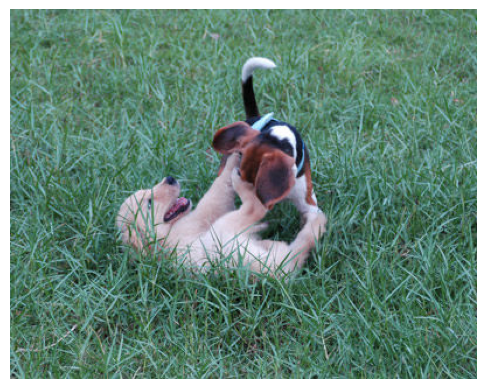

In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.applications.xception import Xception, preprocess_input # Import Xception again
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt
import os

# Load the Xception model (feature extractor) directly here, as the global 'model' might have been overwritten
xception_model_for_captioning = Xception(weights='imagenet', include_top=False, pooling='avg')

# Load the trained captioning model
captioning_model = load_model('image_captioning_model.keras', compile=False) # Compile=False to avoid error if custom_objects are not provided
captioning_model.compile(loss='categorical_crossentropy', optimizer='adam') # Recompile after loading

print("Image captioning model loaded successfully.")

# Function to generate a caption for a given image
def generate_caption(image_path, feature_extractor_model, captioning_model, word_to_idx, idx_to_word, max_caption_length):
    # Extract features from the image using the Xception model
    image_feature = extract_features(image_path, feature_extractor_model) # Use feature_extractor_model

    # Start the caption generation process with 'startseq'
    in_text = 'startseq'
    for i in range(max_caption_length):
        # Convert the current sequence of words to integers
        sequence = [word_to_idx[word] for word in in_text.split() if word in word_to_idx]
        # Pad the sequence to the maximum caption length
        sequence = pad_sequences([sequence], maxlen=max_caption_length, padding='post')[0]

        # Predict the next word
        yhat = captioning_model.predict([image_feature, np.array([sequence])], verbose=0)
        # Get the index of the word with the highest probability
        yhat = np.argmax(yhat)
        # Convert the index to a word
        word = idx_to_word.get(yhat, None)

        # Break if the word is None (unknown) or 'endseq'
        if word is None or word == 'endseq':
            break

        # Append the predicted word to the input sequence
        in_text += ' ' + word

    # Remove 'startseq' from the generated caption
    final_caption = in_text.replace('startseq ', '')
    return final_caption

# --- Manually provide an image path ---
# Upload your image to the Colab environment (e.g., drag and drop to the file browser)
# and then specify its path here.
# For example: custom_image_path = '/content/my_uploaded_image.jpg'
custom_image_path = os.path.join(extract_dir, 'Images', '23445819_3a458716c1.jpg') # Example: using an image already in the dataset
# You can change '3332136681_9aecf101fd.jpg' to any other image filename you want to try.

if os.path.exists(custom_image_path):
    # Generate and print the caption
    generated_caption = generate_caption(custom_image_path, xception_model_for_captioning, captioning_model, word_to_idx, idx_to_word, max_caption_length)
    print(f"\nGenerated Caption for '{os.path.basename(custom_image_path)}': {generated_caption}")

    # Display the image
    img = plt.imread(custom_image_path)
    plt.imshow(img)
    plt.axis('off')
    plt.show()
else:
    print(f"Error: Image not found at {custom_image_path}. Please check the path.")